## Code fonctionnel pour traiter les vidéos et récupérer les valeurs des paramètres

**Traitement des images TIFF et extraction des contours**

L'objectif de cette premiere étape est de charger les images brutes issues de la caméra haute vitesse, d'isoler le profil du drapeau, puis de convertir les coordonnees pixel en dimensions physiques. L'abscisse curviligne est également calculée pour chaque point.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
import glob, sys
import skimage as sk
from matplotlib import rcParams
import tifffile as tif
import gc

"""plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.size": 18,
    "axes.titlesize": 16,
    "axes.labelsize": 18,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 17,
})

plt.close('all')
gc.collect()

fsampling = 1000  
Lflag = 138.5  
scalax = 9.2 
dt = 1 / fsampling  
tmin = 0
tmax = 1

nyorigin = 491
nxorigin = 41

files_list = np.sort(glob.glob('Full-13.4/*.tiff'))
nsnapshots = len(files_list)
Amp_i = np.zeros((nsnapshots))

for i, filei in enumerate(files_list):
    A = tif.imread(filei)
    
    if i == 0:
        A_total = np.tile(np.zeros_like(A), [nsnapshots, 1, 1])
        A_curva_i = np.zeros((nsnapshots, len(A.T))) 
        X_curva_i = np.zeros((nsnapshots, len(A.T))) 
        Y_curva_i = np.zeros((nsnapshots, len(A.T))) 
        S_curva_i = np.zeros((nsnapshots, len(A.T))) 
        
    A_total[i] = A
    A_max_j = np.zeros(len(A.T))
    Int_j = np.zeros(len(A.T))
    umbral_intensidad = sk.filters.threshold_otsu(A)/3

    for j, Aj in enumerate(A.T):
        A_max_j[j] = Aj.argmax()
        Int_j[j] = Aj.max()
        
    Adiff = np.diff(A_max_j)
    Adiff[np.abs(Adiff)>50] = 1000
    nmax  = np.nonzero(Int_j>umbral_intensidad)[0].max()
    A_max_j = A_max_j[:nmax]
    
    A_curva_i[i, :nmax] = A_max_j
    Amp_i[i] = A_max_j[-5:].mean()
    
    x_pixels = np.arange(nmax)
    y_pixels = A_max_j

    x_mm = (x_pixels - nxorigin) / scalax
    y_mm = (nyorigin - y_pixels) / scalax  

    dx = np.diff(x_mm)
    dy = np.diff(y_mm)
    ds = np.sqrt(dx**2 + dy**2)

    s_mm = np.zeros_like(x_mm)
    s_mm[1:] = np.cumsum(ds)

    X_curva_i[i, :nmax] = x_mm
    Y_curva_i[i, :nmax] = y_mm
    S_curva_i[i, :nmax] = s_mm

Astd, Amean = (A_total.std(axis=0), A_total.mean(axis=0))
Imagen_sum = A_total.sum(axis=0)

del(A_total)
gc.collect()

import os
os.makedirs('data_out', exist_ok=True)
np.savez('data_out/full_freq_13.4.npz', 
         A_curva_i=A_curva_i, 
         X_curva_i=X_curva_i, 
         Y_curva_i=Y_curva_i, 
         S_curva_i=S_curva_i, 
         Imagen_sum=Imagen_sum)"""

'plt.rcParams.update({\n    "text.usetex": False,\n    "font.family": "serif",\n    "font.size": 18,\n    "axes.titlesize": 16,\n    "axes.labelsize": 18,\n    "xtick.labelsize": 16,\n    "ytick.labelsize": 16,\n    "legend.fontsize": 17,\n})\n\nplt.close(\'all\')\ngc.collect()\n\nfsampling = 1000  \nLflag = 138.5  \nscalax = 9.2 \ndt = 1 / fsampling  \ntmin = 0\ntmax = 1\n\nnyorigin = 491\nnxorigin = 41\n\nfiles_list = np.sort(glob.glob(\'Full-13.4/*.tiff\'))\nnsnapshots = len(files_list)\nAmp_i = np.zeros((nsnapshots))\n\nfor i, filei in enumerate(files_list):\n    A = tif.imread(filei)\n    \n    if i == 0:\n        A_total = np.tile(np.zeros_like(A), [nsnapshots, 1, 1])\n        A_curva_i = np.zeros((nsnapshots, len(A.T))) \n        X_curva_i = np.zeros((nsnapshots, len(A.T))) \n        Y_curva_i = np.zeros((nsnapshots, len(A.T))) \n        S_curva_i = np.zeros((nsnapshots, len(A.T))) \n        \n    A_total[i] = A\n    A_max_j = np.zeros(len(A.T))\n    Int_j = np.zeros(len(A.T))\n

**Visualisation du profil brut**

Verification de l'extraction des coordonnees sur une image donnee pour valider le traitement optique.

**Ré-échantillonnage et interpolation spatiale uniforme**

Les vecteurs de coordonnées présentent un nombre de points variable selon la courbure. Une interpolation cubique est appliquée pour générer une grille spatiale uniforme et identique pour toutes les observations. Cette étape garantit la stabilité des futurs calculs de derivées spatiales.

In [2]:
import os
from scipy.interpolate import interp1d

scalax = 9.2 
nyorigin = 491
nxorigin = 41
N_points_fixes = 200 

liste_fichiers = glob.glob('data_out/*.npz')
os.makedirs('data_ml_ready', exist_ok=True)

dataset_metadata = []

for fichier in liste_fichiers:
    nom_base = os.path.basename(fichier).replace('.npz', '')
    parties = nom_base.split('_')
    
    if len(parties) >= 3:
        forme = parties[0]
        frequence = float(parties[2])
    else:
        forme = "full"
        frequence = 13.4 

    data = np.load(fichier)
    YT = data['A_curva_i']
    nsnapshots = YT.shape[0]
    
    X_interp = np.zeros((nsnapshots, N_points_fixes))
    Y_interp = np.zeros((nsnapshots, N_points_fixes))
    S_interp = np.zeros((nsnapshots, N_points_fixes))
    
    for i in range(nsnapshots):
        y_brut = YT[i]
        y_sans_mat = y_brut[nxorigin:]
        x_sans_mat = np.arange(nxorigin, len(y_brut))
        
        masque_valide = y_sans_mat > 0 
        y_pixels = y_sans_mat[masque_valide]
        x_pixels = x_sans_mat[masque_valide]
        
        if len(x_pixels) < 10:
            continue
            
        x_mm = (x_pixels - nxorigin) / scalax
        y_mm = (nyorigin - y_pixels) / scalax
        
        dx = np.diff(x_mm)
        dy = np.diff(y_mm)
        ds = np.sqrt(dx**2 + dy**2)
        
        s_mm = np.zeros_like(x_mm)
        s_mm[1:] = np.cumsum(ds)
        
        s_uniforme = np.linspace(0, s_mm.max(), N_points_fixes)
        
        fonction_x = interp1d(s_mm, x_mm, kind='cubic')
        fonction_y = interp1d(s_mm, y_mm, kind='cubic')
        
        X_interp[i, :] = fonction_x(s_uniforme)
        Y_interp[i, :] = fonction_y(s_uniforme)
        S_interp[i, :] = s_uniforme
        
    nom_sauvegarde = f"data_ml_ready/ml_{forme}_freq_{frequence}.npz"
    np.savez(nom_sauvegarde, 
             X=X_interp, 
             Y=Y_interp, 
             S=S_interp, 
             forme=forme, 
             frequence=frequence)
    
    dataset_metadata.append({'fichier': nom_sauvegarde, 'forme': forme, 'frequence': frequence})

**Modèle théorique et méthodologie d'inversion**

Le comportement aéroélastique est modélisé par l'équation de la poutre d'Euler-Bernoulli couplée aux efforts fluides. L'équation régissant le mouvement transversal intègre la masse ajoutée réactive, la tension interne et la traînée de pression externe. L'équation s'écrit sous la forme suivante :

$$(m+M)\ddot{y} + D y'''' - T y'' = - M U^2 y'' - 2M U \dot{y}' - \frac{1}{2}\rho C_d |U y_s + y_t|(U y_s + y_t)$$

La non-dimensionnalisation est effectuée avec les variables suivantes : 
$y = L y^*$, $s = L s^*$, $t = \frac{L}{U} t^*$

L'équation adimensionnée, normalisée par l'inertie globale $(m+M)\frac{U^2}{L}$, isole l'accélération transversale afin de correspondre au formalisme de la régression linéaire :

$$y^*_{t^*t^*} = - \frac{D}{(m+M)U^2 L^2} y^*_{s^*s^*s^*s^*} - \frac{M U^2 - T}{(m+M)U^2} y^*_{s^*s^*} - \frac{2M}{m+M} y^*_{t^*s^*} - \frac{\rho C_d L}{2(m+M)} |y^*_{s^*} + y^*_{t^*}|(y^*_{s^*} + y^*_{t^*})$$

Le traitement des données cinématiques requiert le calcul de dérivées d'ordre élevé. La méthode des différences finies amplifie exponentiellement le bruit optique, rendant la rigidité inobservable. Un filtre de Savitzky-Golay est appliqué avec une fenêtre de lissage polynomiale pour extraire la dérivée spatiale d'ordre 4.

La méthode d'identification délaisse la régularisation Lasso au profit d'une régression par les moindres carrés ordinaires. La régularisation introduit un biais de pénalite qui écrase la valeur réelle des coefficients. Les termes étant connus, la régression standard calcule des valeurs non biaisées.

Plusieurs termes cinématiques ont été volontairement exclus de la matrice d'apprentissage pour des raisons physiques strictes :

1) Le terme quadratique (apparu lors des simulations) est ignoré car il traduit une asymétrie gravitationnelle sans lien avec la mécanique des fluides.
2) L'amortissement visqueux linéaire est supprimé. A haut nombre de Reynolds, le frottement visqueux de la couche limite est négligeable devant la trainée de pression. Sa présence entraîne une colinéarite statistique qui fausse l'évaluation de la résistance fluide.
3) Le terme de saturation cubique est écarté. Ce frein non-linéaire absorbe statistiquement la dissipation d'énergie, ce qui empêche l'algorithme d'attribuer la décélération au coefficient de trainée.

Le modèle conserve explicitement la composante de tension structurelle et la trainée externe. Dans un développement purement analytique, la tension est éliminée par intègration spatiale des forces fluides. Le modèle d'apprentissage étant basé sur des différences locales non intégrées, les deux termes décrivant la contrainte materielle et la pression locale doivent coexister dans la formulation pour découpler les phénomènes.

**Code unifié d'apprentissage et d'analyse inverse**

Le programme suivant opère la dérivation filtrée, définit la matrice des variables d'intêret, résout le systeme linéaire et extrait les propriétés physiques directes par analyse inverse. L'adimensionnement temporel par rapport a la vitesse convective est respecte.

In [3]:
from sklearn.linear_model import LinearRegression
from scipy.interpolate import UnivariateSpline
import numpy as np

def veloc_tunel_ib(frec):
    frecs = np.array([10, 12, 14, 16, 18, 20, 22, 24])
    presiones = np.array([17.2, 26.5, 39.5, 54.5, 73, 93, 115, 141])
    rhoa = 1.2
    pbariloche = 91.92e3
    patm = 101.3e3
    pratio = pbariloche / patm
    rhoa_b = rhoa * pratio
    Veloc = np.sqrt(2 * presiones / rhoa_b)
    p1 = np.polyfit(frecs, Veloc, 1)
    f_vel = np.poly1d(p1)
    return f_vel(frec)

L_flag_mm = 138.5            
L_flag_m = L_flag_mm / 1000  

frequences = [13.4, 17.2]
experiences = {}

mapping_noms = {
    'y': 'C_y',
    'y_ts': 'C_ts',
    'y_s': 'C_s',
    'y_ss': 'C_ss',
    'y_ssss': 'C_ssss',
    'y_resis': 'C_resis'
}

for freq in frequences:
    U_vent = veloc_tunel_ib(freq)
    
    data = np.load(f'data_ml_ready/ml_full_freq_{freq}.npz')
    Y_brut = np.array(data['Y'], dtype=float)
    S_brut = np.array(data['S'][0], dtype=float)

    dt_brut = 1.0 / 1000.0
    ds_brut = S_brut[1] - S_brut[0]

    Y = Y_brut / L_flag_mm 
    ds = ds_brut / L_flag_mm 
    dt = dt_brut * (U_vent / L_flag_m)

    #POD / SVD pour lisser et éviter le bruit
    U_svd, Sigma, V_svd = np.linalg.svd(Y, full_matrices=False)
    K = 3 # On garde les 3 premiers modes
    
    Y = np.dot(U_svd[:, :K], np.dot(np.diag(Sigma[:K]), V_svd[:K, :]))

    print(f"\nCalcul des dérivées spatiales avec UnivariateSpline pour {freq} Hz...")

    Y_s = np.zeros_like(Y)
    Y_ss = np.zeros_like(Y)
    Y_sss = np.zeros_like(Y)
    Y_ssss = np.zeros_like(Y)
    
    s_axis = np.arange(Y.shape[1]) * ds 
    
    # La POD a retiré le bruit ==> facteur très faible pour coller à la physique (la Spline n'a pas besoin de lisser)
    facteur_lissage = 0.001 
    
    for i in range(Y.shape[0]):
        y_signal = Y[i, :]
        spline = UnivariateSpline(s_axis, y_signal, k=5, s=facteur_lissage)
        
        Y_s[i, :]    = spline.derivative(1)(s_axis)
        Y_ss[i, :]   = spline.derivative(2)(s_axis)
        Y_sss[i, :]  = spline.derivative(3)(s_axis)
        Y_ssss[i, :] = spline.derivative(4)(s_axis)
    
    Y_t = np.gradient(Y, dt, axis=0)
    Y_tt = np.gradient(Y_t, dt, axis=0)
    Y_ts = np.gradient(Y_s, dt, axis=0)

    b = 5 
    Y_flat = Y[b:-b, b:-b].flatten()
    Y_t_flat = Y_t[b:-b, b:-b].flatten()
    Y_tt_flat = Y_tt[b:-b, b:-b].flatten()
    Y_ts_flat = Y_ts[b:-b, b:-b].flatten()

    Y_s_flat = Y_s[b:-b, b:-b].flatten()
    Y_ss_flat = Y_ss[b:-b, b:-b].flatten()
    Y_sss_flat = Y_sss[b:-b, b:-b].flatten()
    Y_ssss_flat = Y_ssss[b:-b, b:-b].flatten()

    W_norm = Y_s + Y_t
    Y_resis = np.abs(W_norm) * W_norm
    Y_resis_flat = Y_resis[b:-b, b:-b].flatten()

    X_features = np.column_stack([
        Y_flat, 
        Y_ts_flat,
        Y_s_flat, 
        Y_ss_flat, 
        Y_ssss_flat,
        Y_resis_flat
    ])
    
    feature_names = ['y', 'y_ts', 'y_s', 'y_ss', 'y_ssss', 'y_resis']
    target = Y_tt_flat

    modele = LinearRegression(fit_intercept=False)
    modele.fit(X_features, target)

    print("\n" + "="*50)
    print(f"ML : Fréq = {freq} Hz | Vent (Umax) = {U_vent:.2f} m/s")
    print("="*50)
    
    equation = "Y_tt = "
    for coef, nom in zip(modele.coef_, feature_names):
        if abs(coef) > 1e-3:
            equation += f" + ({coef:.4f} * {nom})"
        else:
            equation += f" + ({coef:.2e} * {nom})"

    print("Équation normalisée :")
    print(equation.replace("=  +", "="))

    data_freq = {"U": U_vent}
    for coef, nom in zip(modele.coef_, feature_names):
        nom_physique = mapping_noms[nom]
        data_freq[nom_physique] = coef
        
    experiences[f"{freq} Hz"] = data_freq

#Analyse inverse pour trouver les paramètres
m_flag = 0.080000      
B_flag = 13.150813e-5  
L_flag = 0.1385
H_flag = 0.200
AR = H_flag / L_flag
rho_air = 1.2 * (91.92e3 / 101.3e3)
Cd_th = 1.8 # Cd 2D utilisé par Eloy

for freq, data in experiences.items():
    U = data["U"]

    print("\n" + "="*50)
    print(f"Physique pour frequence = {freq} (Vent = {U:.2f} m/s)")
    print("="*50)
    
    M_air = (-data["C_ts"] * m_flag) / (2 + data["C_ts"])
    M_totale = m_flag + M_air
    print(f"  > Masse d'air deplacee (M) : {M_air:.5f} kg/m2")
    
    K_rappel = - data["C_y"] * (M_totale * U**2) / (L_flag**2)
    print(f"  > Raideur geometrique (K) : {K_rappel:.2f} N/m3")
    
    Tension_moyenne = (U**2) * (data["C_ss"] * M_totale + M_air)
    print(f"  > Tension moyenne (T) : {Tension_moyenne:.4f} N/m")
    
    T_gradient = data["C_s"] * (M_totale * U**2) / L_flag
    print(f"  > Gradient de Tension (T_s) : {T_gradient:.4f} N/m2")
    
    Cd_calcule = - (2 * M_totale * data["C_resis"]) / (rho_air * L_flag)
    print(f"  > Coefficient de trainee (Cd) mesuré : {Cd_calcule:.3f}")
    
    Cd_experimental = Cd_calcule * 2
    print(f"  > Coefficient de trainee corrigé (*2 car vitesse que sur une face) : {Cd_experimental:.3f}")
    
    Cd_effectif = Cd_th * AR / (AR + 2)
    print(f"  > Coefficient de trainee attendu (Théorie 3D) : {Cd_effectif:.3f}")

    
    D_calcule = abs(data["C_ssss"]) * M_totale * (U**2) * (L_flag**2)
    print(f"  > Rigidite experimentale en vol (D) : {D_calcule:.7e} N.m")
    print(f"    (Reference statique : {B_flag:.7e} N.m)")





Calcul des dérivées spatiales avec UnivariateSpline pour 13.4 Hz...

ML : Fréq = 13.4 Hz | Vent (Umax) = 8.09 m/s
Équation normalisée :
Y_tt = (-0.6388 * y) + (-0.1135 * y_ts) + (-0.1972 * y_s) + (0.0155 * y_ss) + (-2.86e-04 * y_ssss) + (-0.2819 * y_resis)

Calcul des dérivées spatiales avec UnivariateSpline pour 17.2 Hz...

ML : Fréq = 17.2 Hz | Vent (Umax) = 10.95 m/s
Équation normalisée :
Y_tt = (-1.2262 * y) + (-0.2160 * y_ts) + (-0.3379 * y_s) + (0.0118 * y_ss) + (9.83e-05 * y_ssss) + (-0.1581 * y_resis)

Physique pour frequence = 13.4 Hz (Vent = 8.09 m/s)
  > Masse d'air deplacee (M) : 0.00481 kg/m2
  > Raideur geometrique (K) : 184.98 N/m3
  > Tension moyenne (T) : 0.4014 N/m
  > Gradient de Tension (T_s) : -7.9102 N/m2
  > Coefficient de trainee (Cd) mesuré : 0.317
  > Coefficient de trainee corrigé (*2 car vitesse que sur une face) : 0.634
  > Coefficient de trainee attendu (Théorie 3D) : 0.755
  > Rigidite experimentale en vol (D) : 3.0443348e-05 N.m
    (Reference statique 

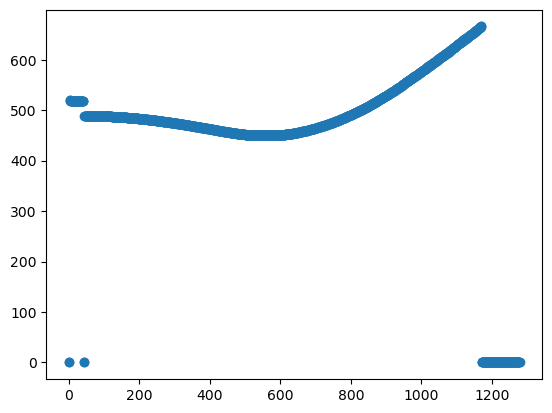

In [5]:
import matplotlib.pyplot as plt
import gc

plt.close('all')
gc.collect()

A = np.load('full_freq_13.4.npz')
Asum = A['Imagen_sum']
YT = A['A_curva_i']

fig, ax = plt.subplots()
ax.plot(YT[10], 'o')
plt.show()

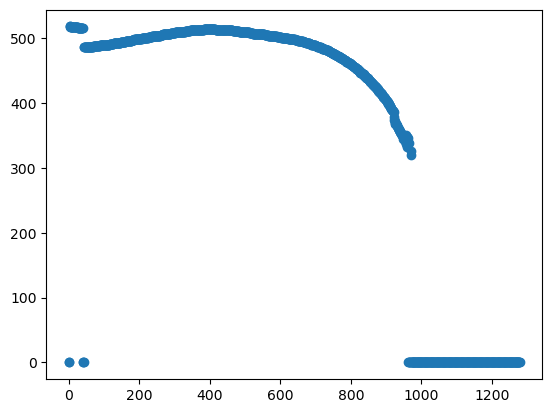

In [6]:
plt.close('all')
gc.collect()

A = np.load('full_freq_17.2.npz')
Asum = A['Imagen_sum']
YT = A['A_curva_i']

fig, ax = plt.subplots()
ax.plot(YT[10], 'o')
plt.show()